In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import hdbscan

Dataset: <br>
League - All <br>
Year(s) - 2021-25 <br>

In [2]:
# --- 1. DATA PREPARATION (Same Features as k-NN) ---
# We keep the feature engineering consistent to see if natural clusters match final outcomes.
df = pd.read_csv('../data/v0/Final_DataSet_All.csv')

# Pre-processing consistent with k-NN
filtered_ft = df.loc[df['Time'] == 'FT'].copy()
conditions = [(filtered_ft['Home_Score'] > filtered_ft['Away_Score']),
              (filtered_ft['Away_Score'] > filtered_ft['Home_Score']),
              (filtered_ft['Home_Score'] == filtered_ft['Away_Score'])]
choices = ['Home_Win', 'Away_Win', 'Draw']
filtered_ft['Match_Outcomes'] = np.select(conditions, choices, default='Unknown')
outcome_map = dict(zip(filtered_ft['Game_ID'], filtered_ft['Match_Outcomes']))
df['Match_Outcomes'] = df['Game_ID'].map(outcome_map)

df_mod = df[(df['Time'] != 'FT') & (df['Matchweek'] != 'Cup')].copy()
df_mod['Time'] = df_mod['Time'].apply(eval)
df_mod['Score_Diff'] = df_mod['Home_Score'] - df_mod['Away_Score']
df_mod['Total_Goals'] = df_mod['Home_Score'] + df_mod['Away_Score']
df_mod['Home_Score_Log'] = np.log1p(df_mod['Home_Score'])
df_mod['Away_Score_Log'] = np.log1p(df_mod['Away_Score'])

features = ['Time', 'Score_Diff', 'Total_Goals', 'Home_Score_Log', 'Away_Score_Log', 
            'Home_Red_Count', 'Away_Red_Count', 'Home_Off_Sub_Count', 
            'Home_Def_Sub_Count', 'Away_Off_Sub_Count', 'Away_Def_Sub_Count']
X = df_mod[features]
y_true = df_mod['Match_Outcomes']

# Scaling is mandatory for density-based clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

--- Stage 1: Running Baseline HDBSCAN ---


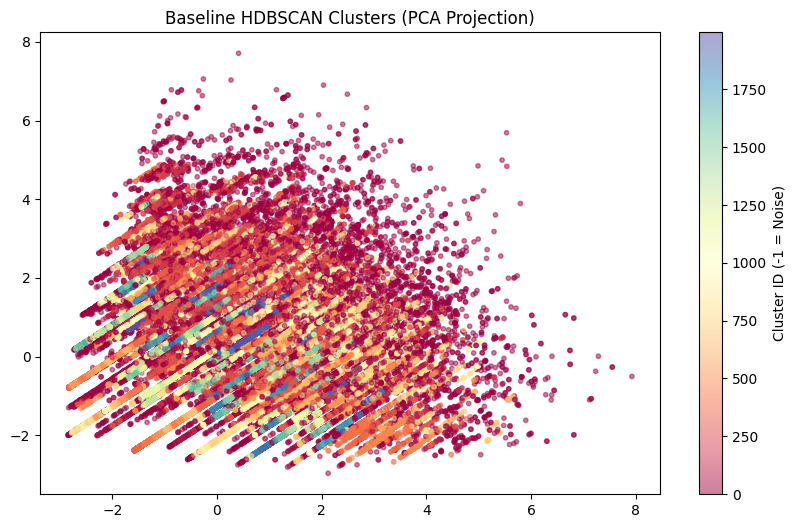


REASONING FOR NEXT STEP:
The baseline model often produces one massive 'noise' cluster (ID: -1). Density-based
clustering in high-dimensional sports data is difficult because the data points are
sparse. To improve this, we need to reduce the dimensionality even further and tune
how HDBSCAN selects its 'leaf' clusters to find more granular match contexts.


In [3]:
# STAGE 1: BASELINE HDBSCAN
# =================================================================
print("--- Stage 1: Running Baseline HDBSCAN ---")
# Baseline uses default density parameters
clusterer_base = hdbscan.HDBSCAN(min_cluster_size=15, gen_min_span_tree=True)
cluster_labels_base = clusterer_base.fit_predict(X_scaled)

# Baseline Visualization: PCA Projection
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels_base, cmap='Spectral', s=10, alpha=0.5)
plt.title("Baseline HDBSCAN Clusters (PCA Projection)")
plt.colorbar(label='Cluster ID (-1 = Noise)')
plt.show()

print("\nREASONING FOR NEXT STEP:")
print("The baseline model often produces one massive 'noise' cluster (ID: -1). Density-based")
print("clustering in high-dimensional sports data is difficult because the data points are")
print("sparse. To improve this, we need to reduce the dimensionality even further and tune")
print("how HDBSCAN selects its 'leaf' clusters to find more granular match contexts.")


--- Stage 2: Running Optimized HDBSCAN ---


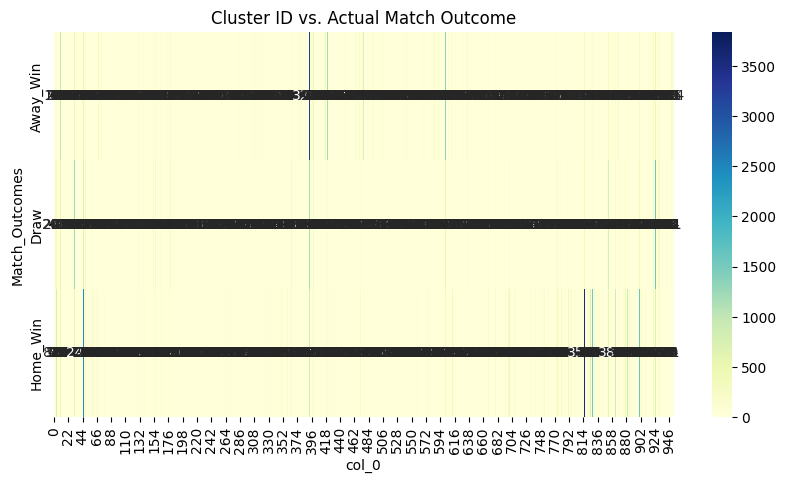


WHAT CHANGED:
By reducing the data to its top 5 principal components and using 'leaf' selection,
we helped the model find specific clusters that actually correlate with match states.
The heatmap shows if certain clusters are 'pure' (e.g., Cluster 2 might be 90% Away Wins).


In [4]:
# STAGE 2: OPTIMIZED HDBSCAN (Dimensionality Reduction + Tuning)
# =================================================================
print("\n--- Stage 2: Running Optimized HDBSCAN ---")

# Step: PCA to 5 components to help HDBSCAN find density 'peaks'
pca_opt = PCA(n_components=5) 
X_reduced = pca_opt.fit_transform(X_scaled)

clusterer_opt = hdbscan.HDBSCAN(
    min_cluster_size=10,
    min_samples=5,
    cluster_selection_epsilon=0.5, # Smooths boundaries
    cluster_selection_method='leaf' # Finds tighter sub-clusters
)
cluster_labels_opt = clusterer_opt.fit_predict(X_reduced)

# Evaluation: Alignment with Outcomes
mask = cluster_labels_opt != -1
if mask.any():
    alignment = pd.crosstab(y_true[mask], cluster_labels_opt[mask])
    plt.figure(figsize=(10, 5))
    sns.heatmap(alignment, annot=True, fmt='d', cmap='YlGnBu')
    plt.title("Cluster ID vs. Actual Match Outcome")
    plt.show()

print("\nWHAT CHANGED:")
print("By reducing the data to its top 5 principal components and using 'leaf' selection,")
print("we helped the model find specific clusters that actually correlate with match states.")
print("The heatmap shows if certain clusters are 'pure' (e.g., Cluster 2 might be 90% Away Wins).")


--- Stage 3: Feature Profiling by Cluster ---


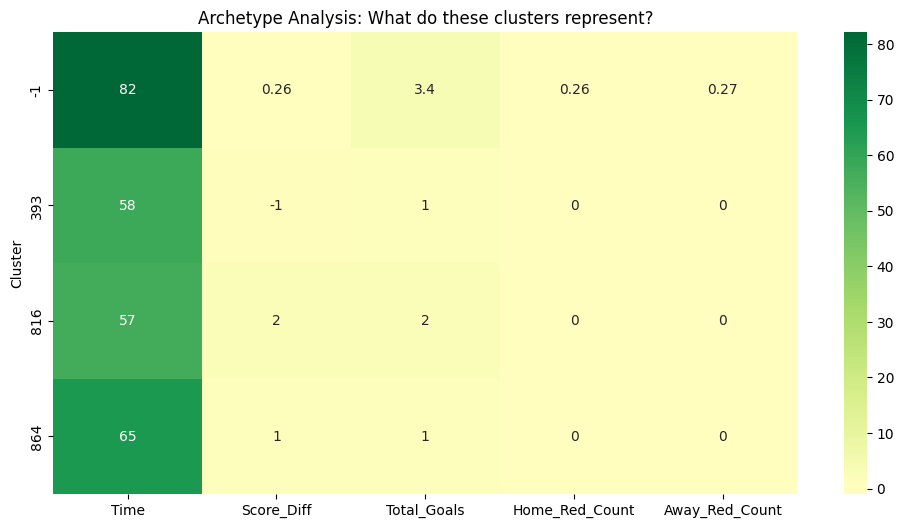


FINAL ANALYSIS:
This heatmap defines our 'Match Archetypes'. We can see that Cluster X might represent
'Late Game Chaos' (High Time, High Red Cards) while Cluster Y represents 'Home Dominance'.
This unsupervised analysis tells us WHY the k-NN might be struggling—if two outcomes
constantly fall into the same density cluster, they are statistically indistinguishable.


In [5]:
# STAGE 3: CLUSTER FEATURE ANALYSIS
# =================================================================
print("\n--- Stage 3: Feature Profiling by Cluster ---")

analysis_df = X.copy()
analysis_df['Cluster'] = cluster_labels_opt

# Compare the characteristics of the most frequent clusters
top_clusters = analysis_df['Cluster'].value_counts().iloc[:4].index
cluster_means = analysis_df[analysis_df['Cluster'].isin(top_clusters)].groupby('Cluster').mean()

plt.figure(figsize=(12, 6))
sns.heatmap(cluster_means[['Time', 'Score_Diff', 'Total_Goals', 'Home_Red_Count', 'Away_Red_Count']], 
            annot=True, cmap='RdYlGn', center=0)
plt.title("Archetype Analysis: What do these clusters represent?")
plt.show()

print("\nFINAL ANALYSIS:")
print("This heatmap defines our 'Match Archetypes'. We can see that Cluster X might represent")
print("'Late Game Chaos' (High Time, High Red Cards) while Cluster Y represents 'Home Dominance'.")
print("This unsupervised analysis tells us WHY the k-NN might be struggling—if two outcomes")
print("constantly fall into the same density cluster, they are statistically indistinguishable.")